In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')


In [25]:
df=pd.read_csv('sales.csv')

In [26]:
df[df['store']=='Lower Manhattan']

,order_id,date,store,product,quantity,sales
0,1,01/01/2023,Lower Manhattan,Gourmet brewed coffee,2,6.00
1,2,01/01/2023,Lower Manhattan,Brewed Chai tea,2,6.20
2,3,01/01/2023,Lower Manhattan,Hot chocolate,2,9.00
3,4,01/01/2023,Lower Manhattan,Drip coffee,1,2.00
4,5,01/01/2023,Lower Manhattan,Brewed Chai tea,2,6.20
...,...,...,...,...,...,...
149045,149386,30/06/2023,Lower Manhattan,Drip coffee,2,4.00
149046,149387,30/06/2023,Lower Manhattan,Hot chocolate,1,4.50
149047,149388,30/06/2023,Lower Manhattan,Scone,1,3.25
149094,149435,30/06/2023,Lower Manhattan,Hot chocolate,2,7.00


In [27]:
df.head()

,order_id,date,store,product,quantity,sales
0,1,01/01/2023,Lower Manhattan,Gourmet brewed coffee,2,6.0
1,2,01/01/2023,Lower Manhattan,Brewed Chai tea,2,6.2
2,3,01/01/2023,Lower Manhattan,Hot chocolate,2,9.0
3,4,01/01/2023,Lower Manhattan,Drip coffee,1,2.0
4,5,01/01/2023,Lower Manhattan,Brewed Chai tea,2,6.2


In [28]:
df.shape

(149116, 6)

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149116 entries, 0 to 149115
Data columns (total 6 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   order_id  149116 non-null  int64  
 1   date      149116 non-null  object 
 2   store     149116 non-null  object 
 3   product   149116 non-null  object 
 4   quantity  149116 non-null  int64  
 5   sales     149116 non-null  float64
dtypes: float64(1), int64(2), object(3)
memory usage: 6.8+ MB


In [30]:
df.isnull().sum()

order_id    0
date        0
store       0
product     0
quantity    0
sales       0
dtype: int64

In [31]:
df.describe()

,order_id,quantity,sales
count,149116.000000,149116.000000,149116.000000
mean,74737.371872,1.438276,4.686367
std,43153.600016,0.542509,4.227099
min,1.000000,1.000000,0.800000
25%,37335.750000,1.000000,3.000000
50%,74727.500000,1.000000,3.750000
75%,112094.250000,2.000000,6.000000
max,149456.000000,8.000000,360.000000


In [32]:
df.sales.describe()

count    149116.000000
mean          4.686367
std           4.227099
min           0.800000
25%           3.000000
50%           3.750000
75%           6.000000
max         360.000000
Name: sales, dtype: float64

In [33]:
df.skew(numeric_only=True)

order_id     0.000062
quantity     0.799819
sales       41.745899
dtype: float64

In [34]:
df.kurtosis(numeric_only=True)

order_id      -1.200451
quantity       0.823692
sales       3359.754589
dtype: float64

array([[<Axes: title={'center': 'order_id'}>,
        <Axes: title={'center': 'quantity'}>],
       [<Axes: title={'center': 'sales'}>, <Axes: >]], dtype=object)

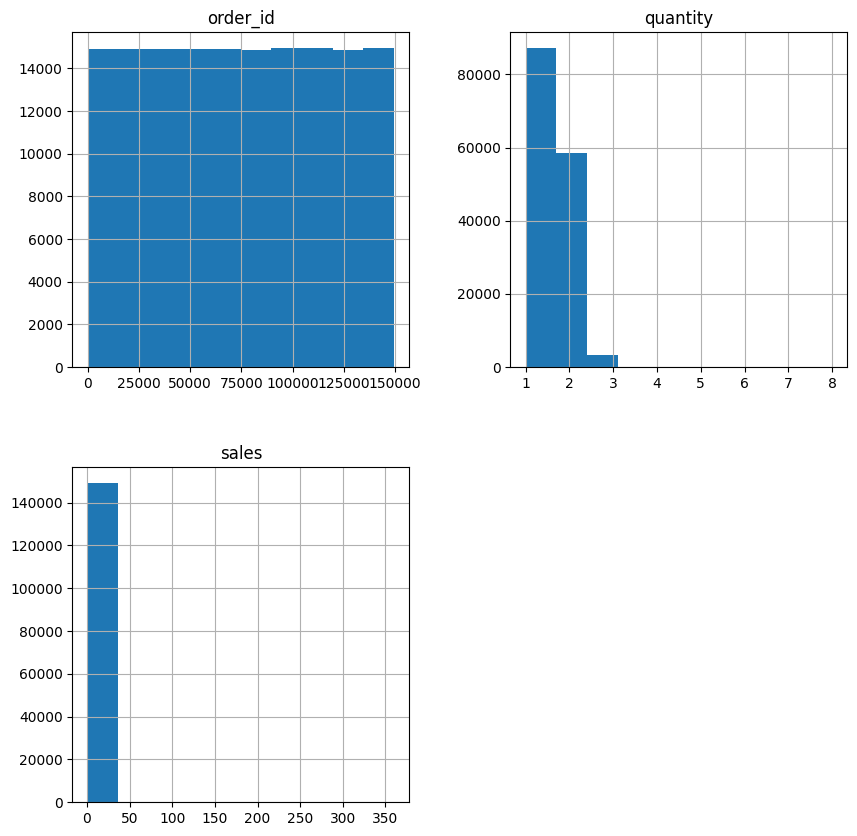

In [35]:
features = ['order_id', 'quantity', 'sales'] # create a list of all numerical features
df[features].hist(figsize=(10,10))

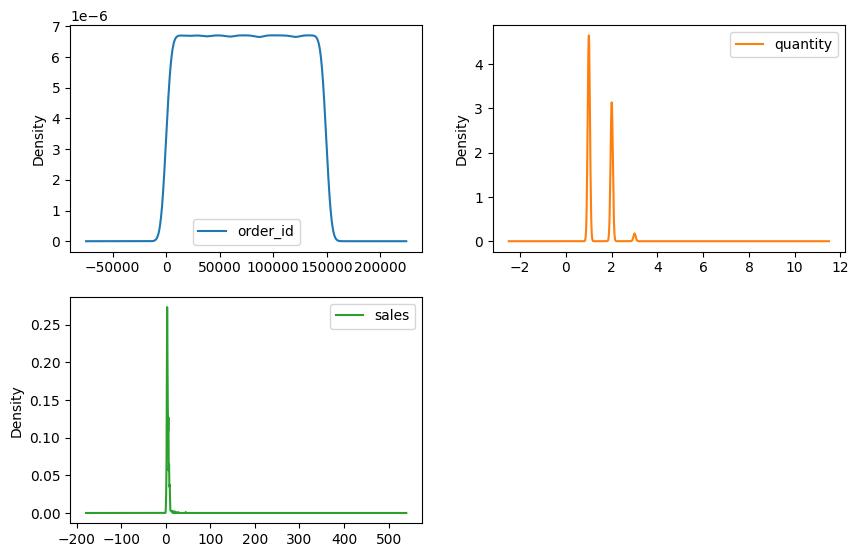

In [36]:
df[features].plot(kind='density', subplots=True, layout=(3, 2), sharex=False, figsize=(10, 10));

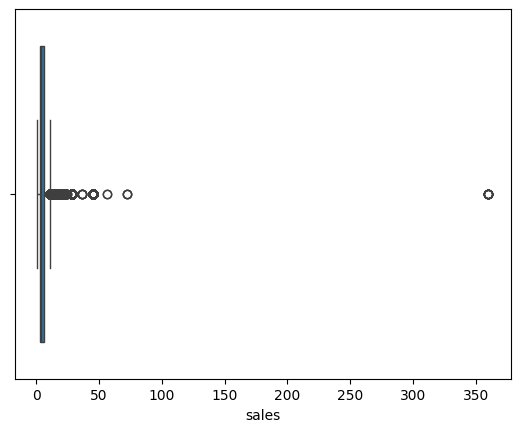

In [38]:
sns.boxplot(x='sales', data=df);

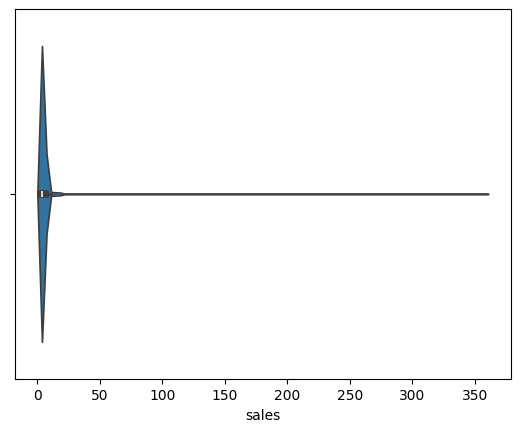

In [39]:
sns.violinplot(x='sales', data=df);

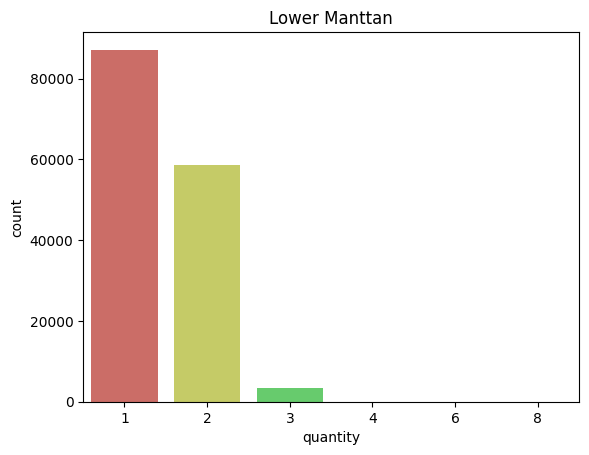

In [40]:
sns.countplot(x = 'quantity', data = df, palette="hls")
plt.title("Lower Manttan");

In [41]:
df.corr(numeric_only=True)

,order_id,quantity,sales
order_id,1.000000,0.010250,0.005949
quantity,0.010250,1.000000,0.356231
sales,0.005949,0.356231,1.000000


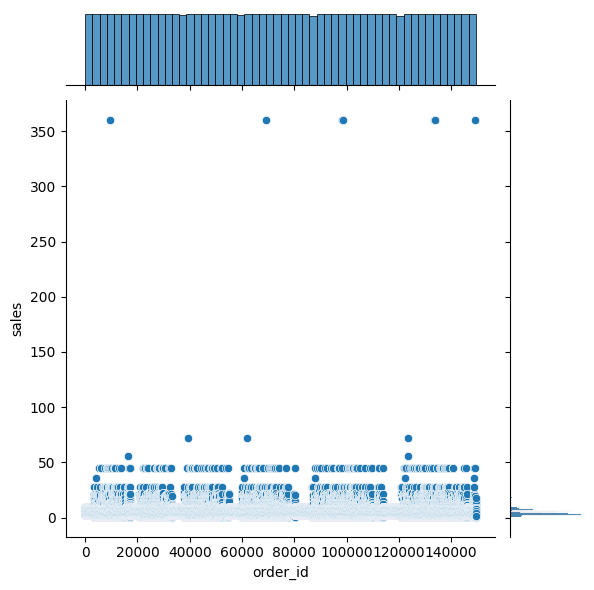

In [42]:
sns.jointplot(x = 'order_id', y = 'sales', data = df);

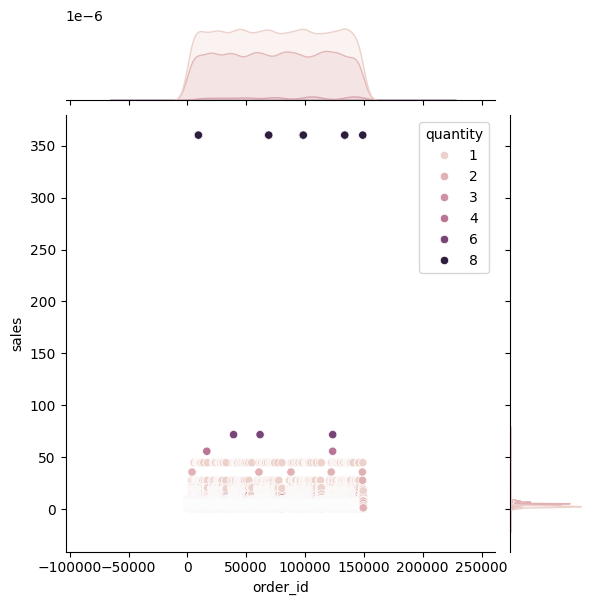

In [43]:
sns.jointplot(x = 'order_id', y = 'sales', data = df, hue='quantity');

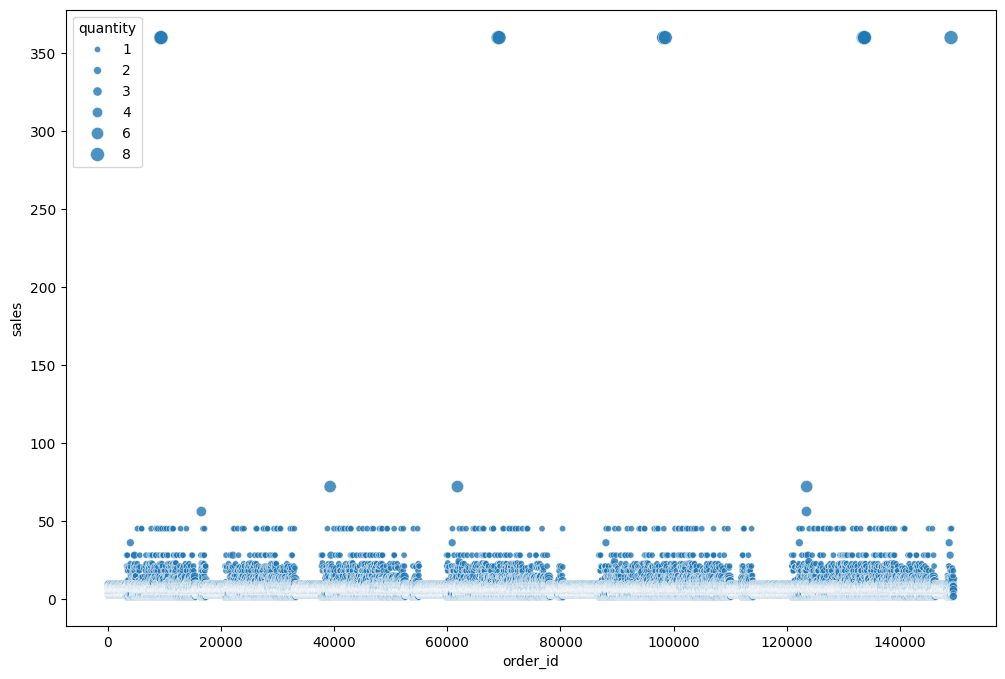

In [44]:
plt.figure(figsize=(12,8))
sns.scatterplot(x="order_id", 
                y="sales",
                size="quantity",
                sizes=(20,100),
                alpha=0.8,
                data=df);